# GradeScope — 03. Selekcja cech

**Cel:** wybranie najważniejszych cech za pomocą Feature Importance (RandomForest) oraz porównanie z PCA

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Wczytanie danych z preprocessingu
with open("../data/splits.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
feature_names = data["feature_names"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (5285, 19), X_test: (1322, 19)


## 1. Feature Importance — RandomForest

Feature Importance (malejąco):
   1. Attendance                          0.3808
   2. Hours_Studied                       0.2016
   3. Previous_Scores                     0.0803
   4. Tutoring_Sessions                   0.0398
   5. Sleep_Hours                         0.0340
   6. Parental_Involvement                0.0299
   7. Access_to_Resources                 0.0298
   8. Physical_Activity                   0.0280
   9. Peer_Influence                      0.0235
  10. Family_Income                       0.0219
  11. Parental_Education_Level            0.0213
  12. Distance_from_Home                  0.0202
  13. Motivation_Level                    0.0201
  14. Teacher_Quality                     0.0163
  15. Extracurricular_Activities          0.0127
  16. Gender                              0.0115
  17. School_Type                         0.0106
  18. Learning_Disabilities               0.0097
  19. Internet_Access                     0.0079


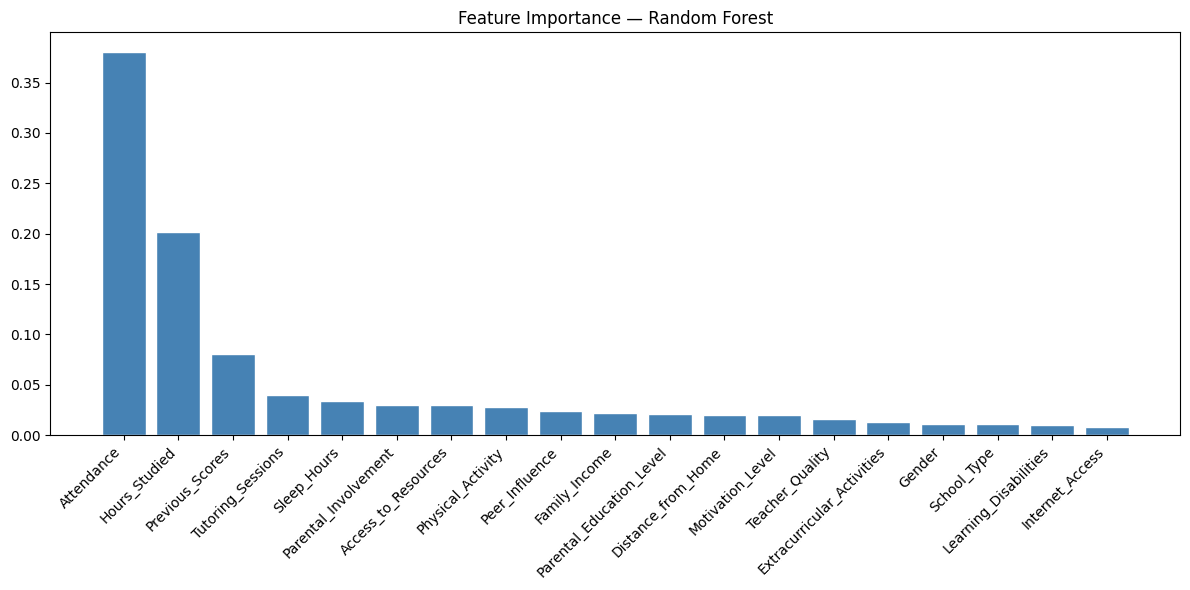

In [8]:
# Szybki RF do oceny ważności cech
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature Importance (malejąco):")
for i, idx in enumerate(indices):
    print(f"  {i+1:2}. {feature_names[idx]:<35} {importances[idx]:.4f}")

# Wykres
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_names)), importances[indices], color="steelblue", edgecolor="white")
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha="right")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("../report/fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Wybór top cech

In [9]:
# Top 12 cech — zachowuje >95% accuracy względem pełnego zestawu przy znacznie mniejszym wejściu
TOP_N = 12

selected_features = [feature_names[i] for i in indices[:TOP_N]]
print(f"Wybrane cechy (top {TOP_N}):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2}. {f}")

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Weryfikacja accuracy po selekcji
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X_train_sel, y_train)
acc_all = accuracy_score(y_test, rf.predict(X_test))
acc_sel = accuracy_score(y_test, rf_sel.predict(X_test_sel))

print(f"\nAccuracy — wszystkie cechy ({len(feature_names)}): {acc_all:.4f}")
print(f"Accuracy — top {TOP_N} cech:                    {acc_sel:.4f}")

Wybrane cechy (top 12):
   1. Attendance
   2. Hours_Studied
   3. Previous_Scores
   4. Tutoring_Sessions
   5. Sleep_Hours
   6. Parental_Involvement
   7. Access_to_Resources
   8. Physical_Activity
   9. Peer_Influence
  10. Family_Income
  11. Parental_Education_Level
  12. Distance_from_Home

Accuracy — wszystkie cechy (19): 0.9017
Accuracy — top 12 cech:                    0.8918


## 3. Porównanie z PCA

In [10]:
# PCA jako alternatywa do feature selection — porównanie accuracy przy tej samej liczbie wymiarów
# PCA wymaga standaryzacji
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# PCA z 10 komponentami
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

explained = pca.explained_variance_ratio_.cumsum()
print(f"Wyjaśniona wariancja (10 komponentów): {explained[-1]:.4f}")

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, rf_pca.predict(X_test_pca))

print(f"\nPorównanie accuracy:")
print(f"  Wszystkie cechy (19):  {acc_all:.4f}")
print(f"  Top {TOP_N} cech:           {acc_sel:.4f}")
print(f"  PCA (10 komponentów):  {acc_pca:.4f}")

Wyjaśniona wariancja (10 komponentów): 0.5509

Porównanie accuracy:
  Wszystkie cechy (19):  0.9017
  Top 12 cech:           0.8918
  PCA (10 komponentów):  0.7322


## 4. Zapis wybranych cech

In [ ]:
# Zapis wybranych cech do pliku — używany w kolejnych notebookach
with open("../data/selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

print(f"Zapisano {len(selected_features)} cech: {selected_features}")

Zapisano 12 cech: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Sleep_Hours', 'Parental_Involvement', 'Access_to_Resources', 'Physical_Activity', 'Peer_Influence', 'Family_Income', 'Parental_Education_Level', 'Distance_from_Home']
